# OCR with EMNIST demo


In [1]:
!pip install matplotlib opencv-python
!pip install torch torchvision torchaudio
import matplotlib.pyplot as plt
import cv2
import os

from nets import LeNet_NClasses_batchnorm
import train
from segment import *

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


Load sample images
---

In [2]:
images = {
    "digits" : cv2.cvtColor(cv2.imread("./raw_images/digits.jpg"),cv2.COLOR_BGR2RGB),
    "capsletters": cv2.cvtColor(cv2.imread("./raw_images/latin_caps.jpg"),cv2.COLOR_BGR2RGB),
    "greek"  : cv2.cvtColor(cv2.imread("./raw_images/greek_lower.jpg"),cv2.COLOR_BGR2RGB),
    "nonalphanum" : cv2.cvtColor(cv2.imread("./raw_images/nonalphanum.jpg"),cv2.COLOR_BGR2RGB),
    "pangram" : cv2.cvtColor(cv2.imread("./raw_images/pangram.jpg"),cv2.COLOR_BGR2RGB)
}

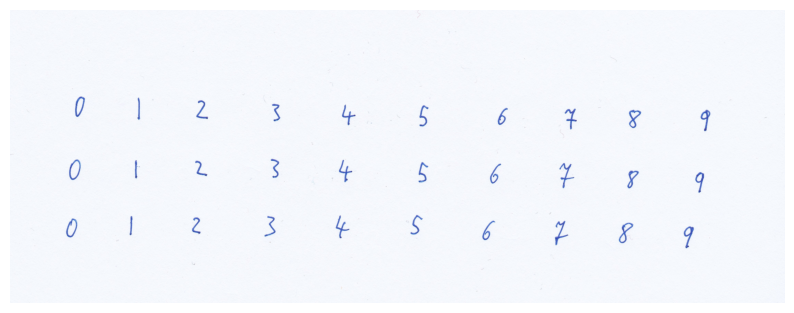

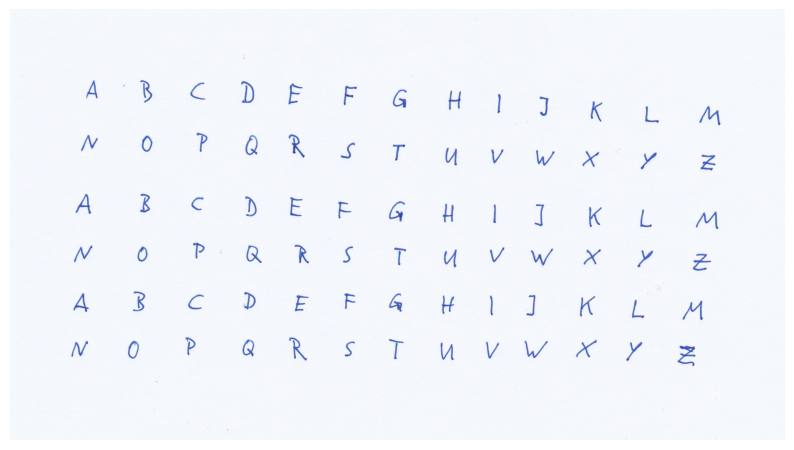

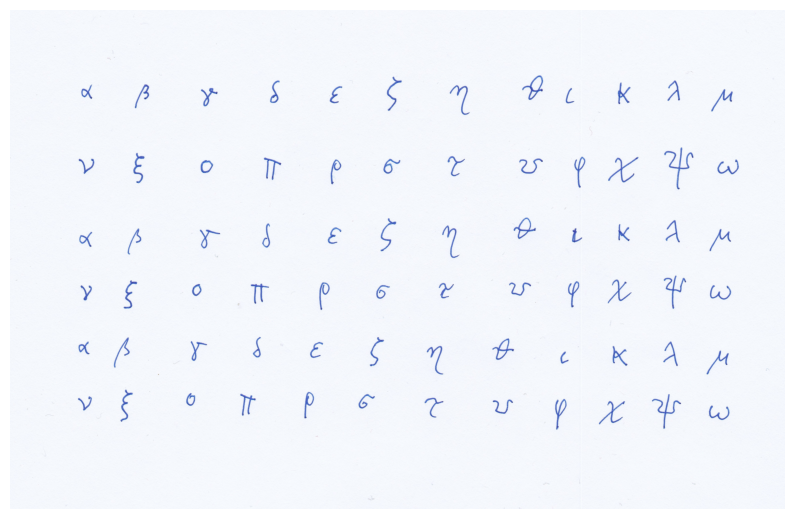

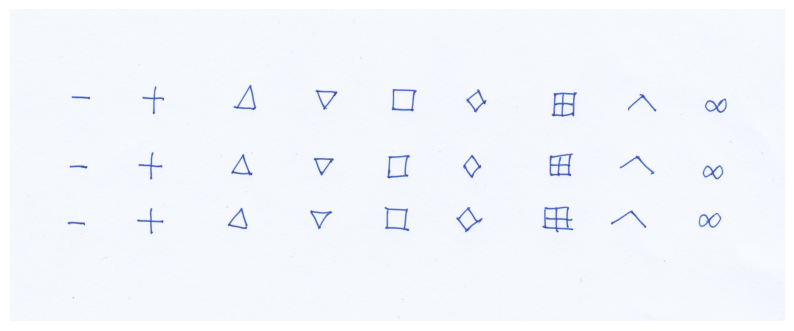

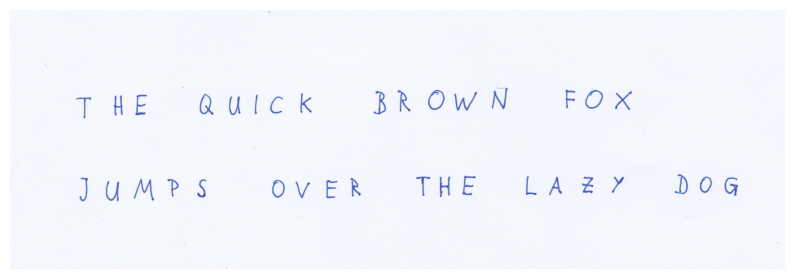

In [3]:
for img in images.values():
    plt.figure(figsize=(10,10))    
    plt.imshow(img)
    plt.axis("off")

Load/train model
---

In [4]:
LENET_CAPS_PATH = "./lenet_caps_parameters.pth"   

if not os.path.exists(LENET_CAPS_PATH):
    train.train_caps(LENET_CAPS_PATH)
    
cnn_caps = LeNet_NClasses_batchnorm(26)
cnn_caps.load_state_dict(torch.load(LENET_CAPS_PATH))
cnn_caps = cnn_caps.eval()

# Letter detection

The classifier has been trained on the upper case letters of the **By_Class** split of the EMNIST dataset.
The softmax probabilites are thresholded at 0.9 to avoid the detection of characters that are not upper case latin letters. This works to some extent.

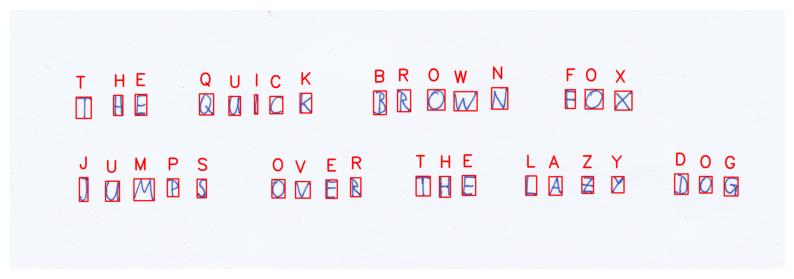

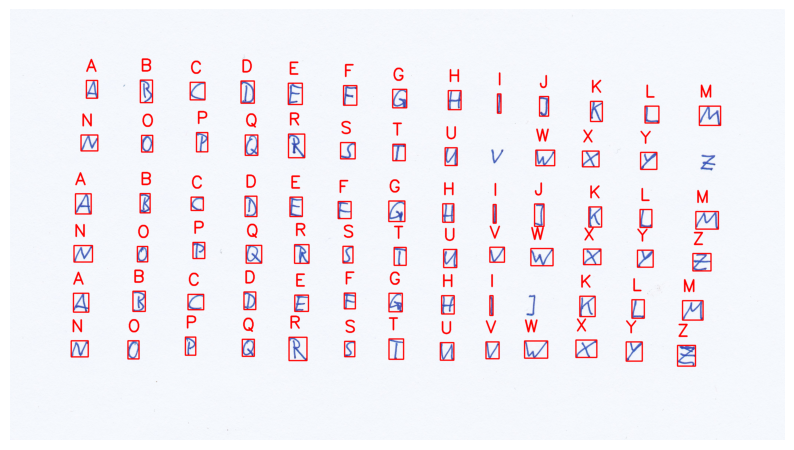

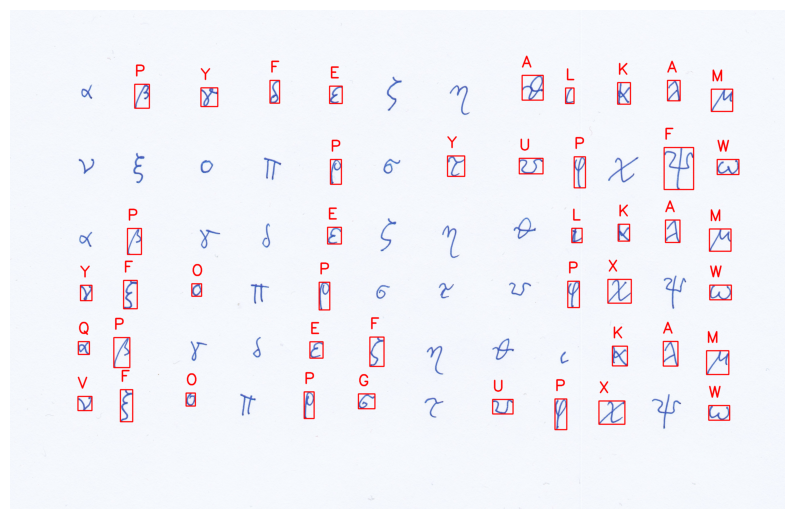

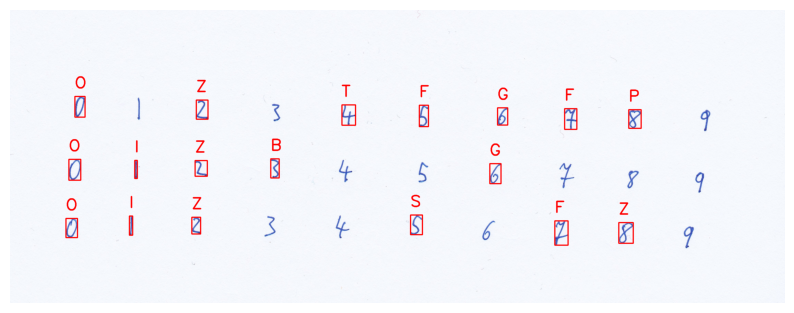

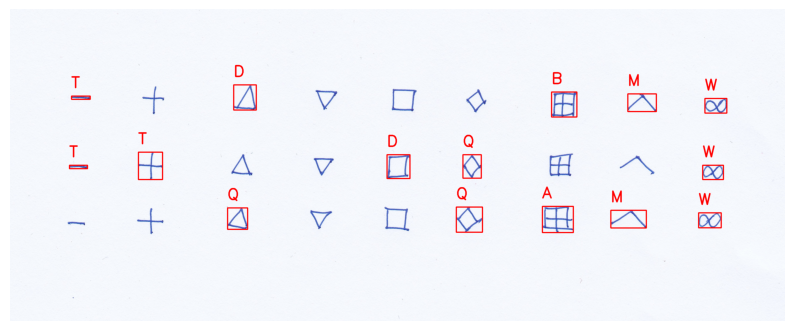

In [5]:
caps_labels = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"


plt.figure(figsize=(10,10))
plt.imshow(detectandlabel(cnn_caps,images["pangram"],caps_labels,thresh=0.9))
plt.axis("off")
plt.savefig("pangram_demo.jpg",bbox_inches='tight')

for key in ["capsletters","greek","digits","nonalphanum"]:
    plt.figure(figsize=(10,10))
    plt.imshow(detectandlabel(cnn_caps,images[key],caps_labels,thresh=0.9))
    plt.axis("off")

# Demo of the image segmentation pipeline

ROI detection
---

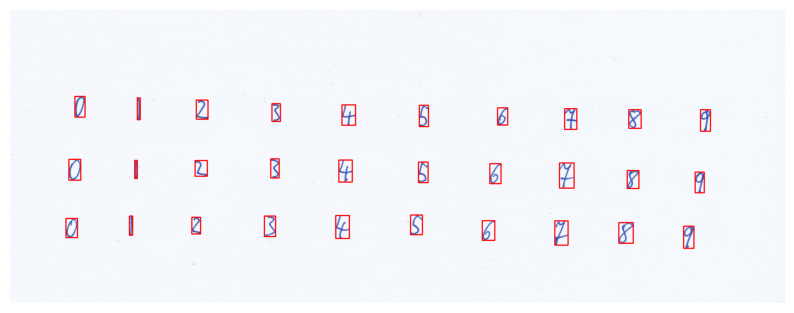

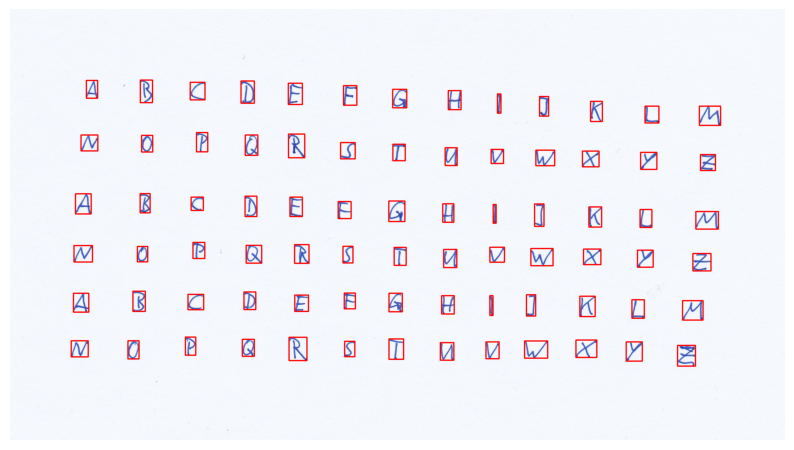

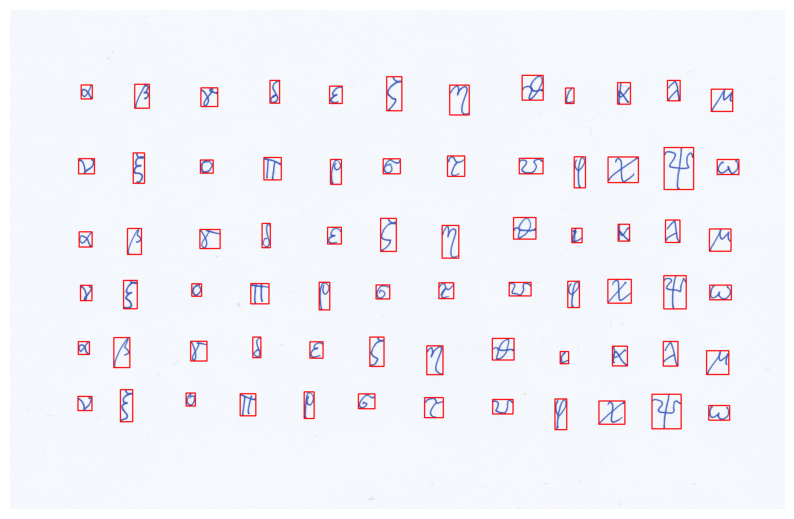

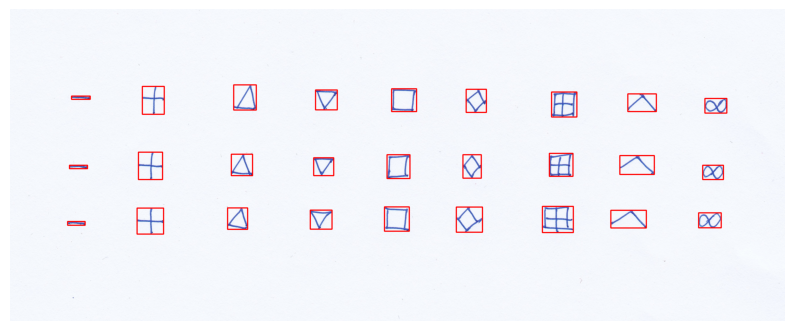

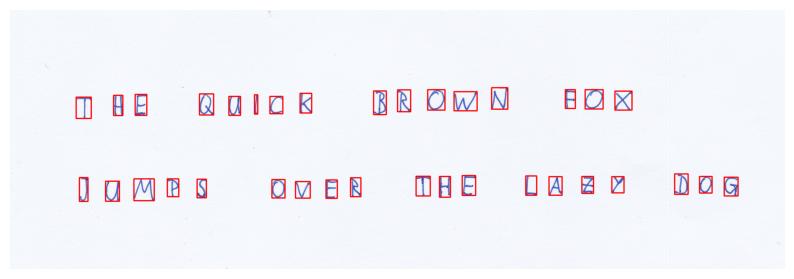

In [6]:
for img in images.values():
    plt.figure(figsize=(10,10))    
    plt.imshow(detectanddrawbb(img))
    plt.axis("off")

Wrangling of ROIs into 28x28 grayscale images
---

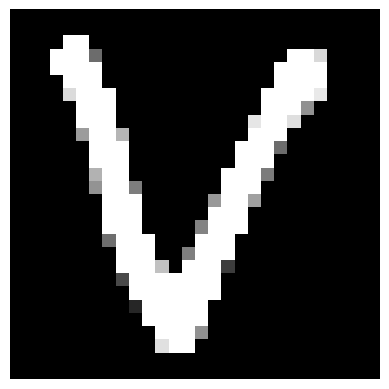

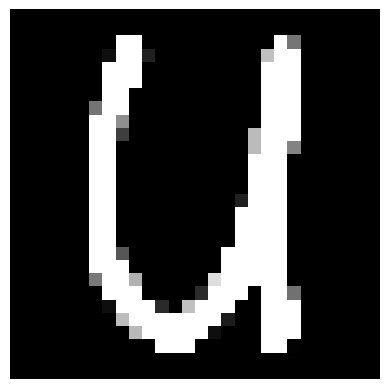

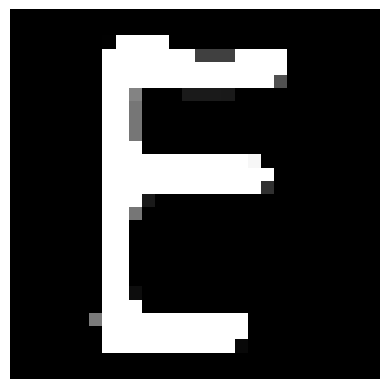

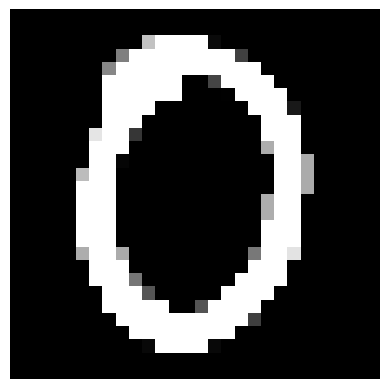

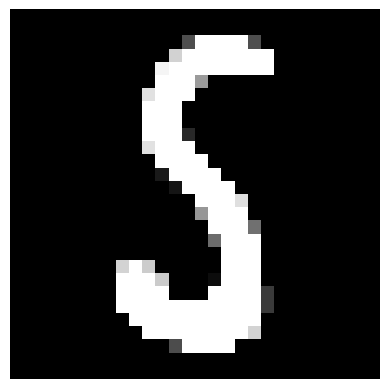

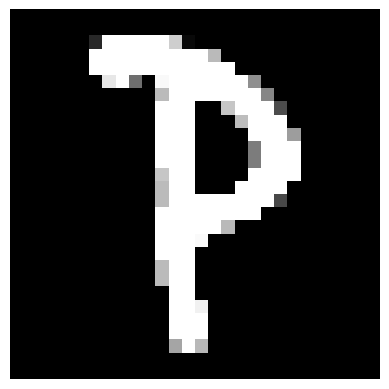

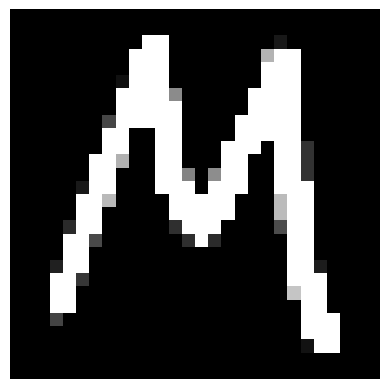

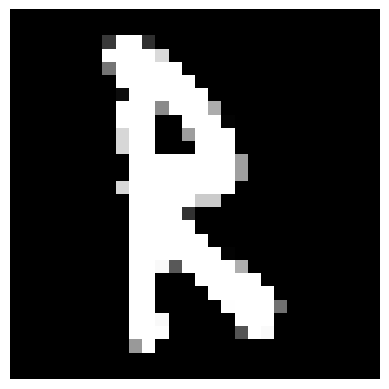

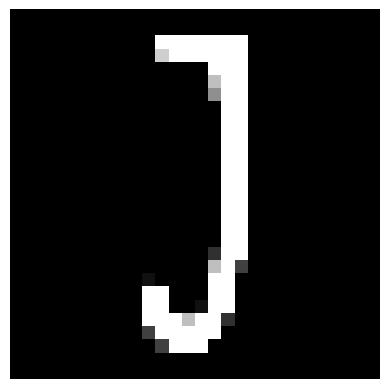

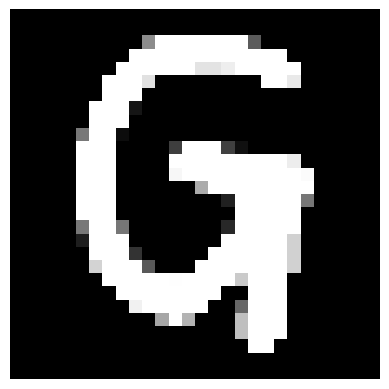

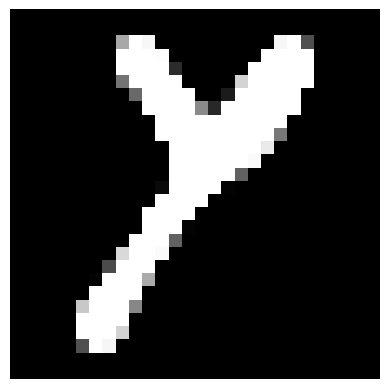

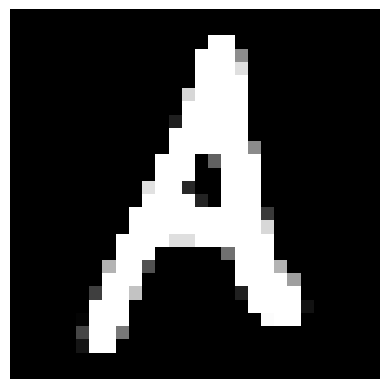

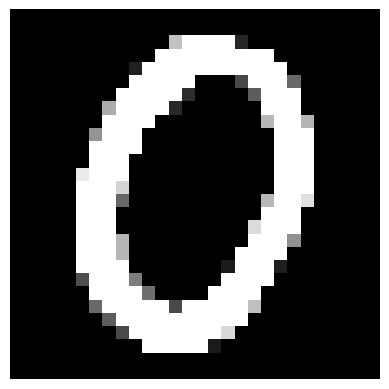

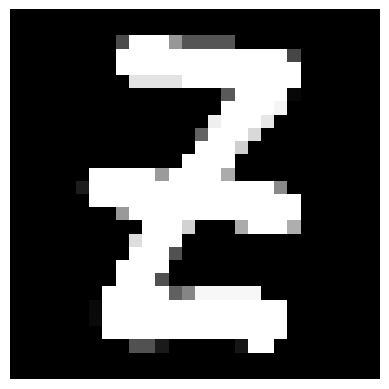

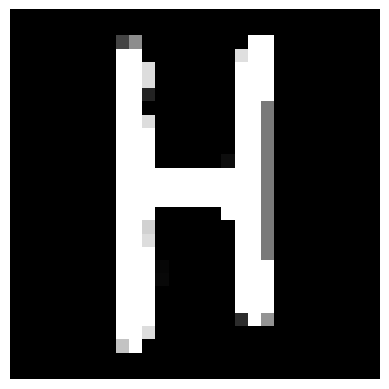

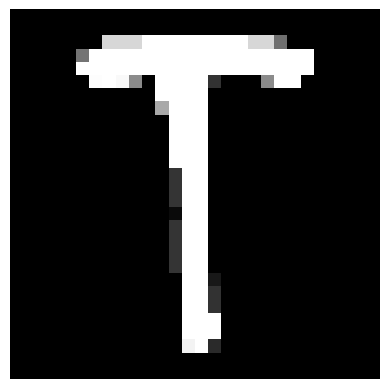

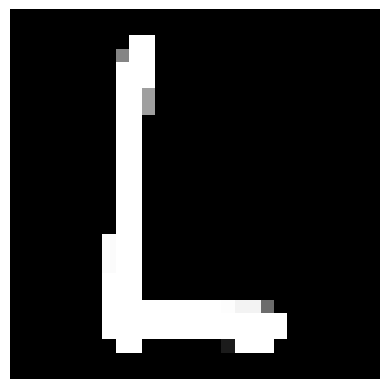

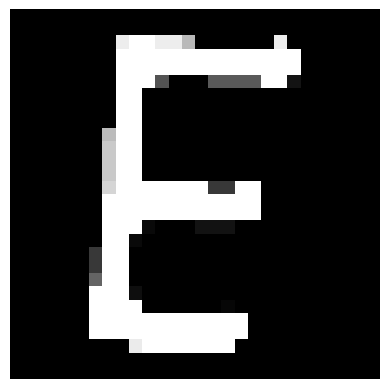

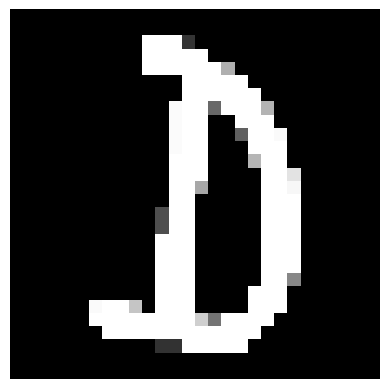

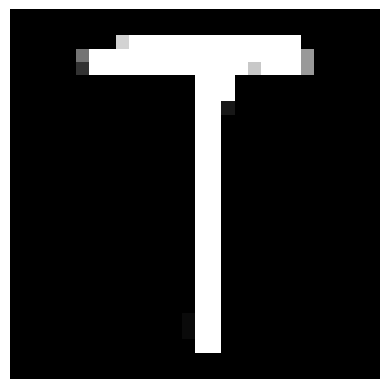

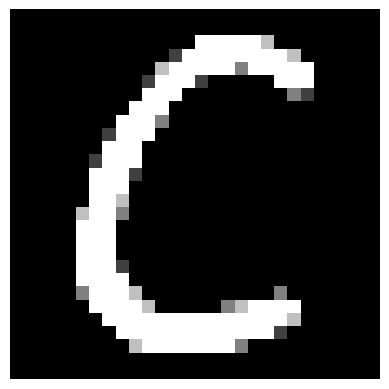

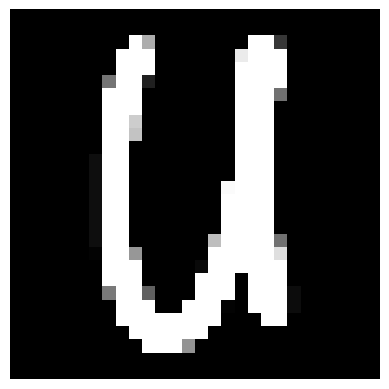

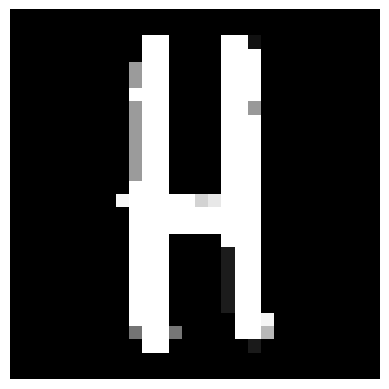

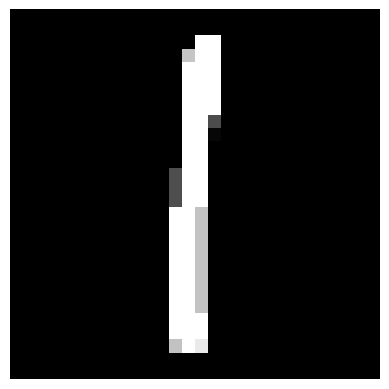

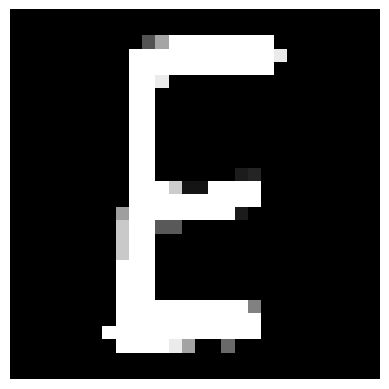

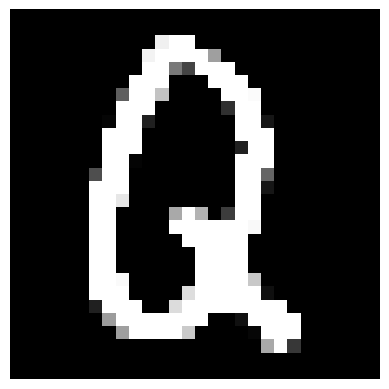

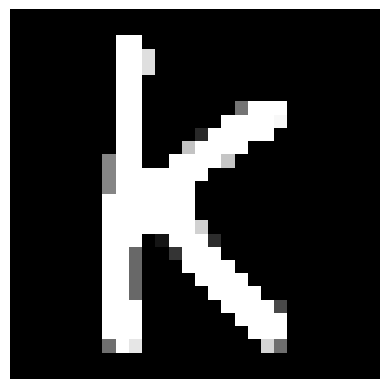

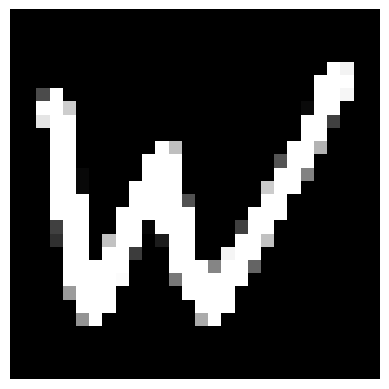

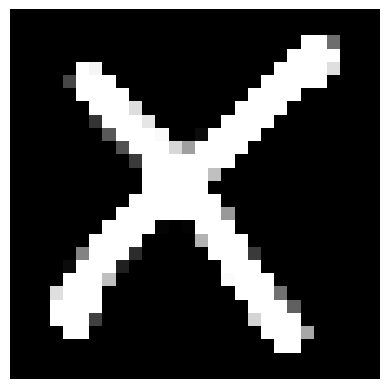

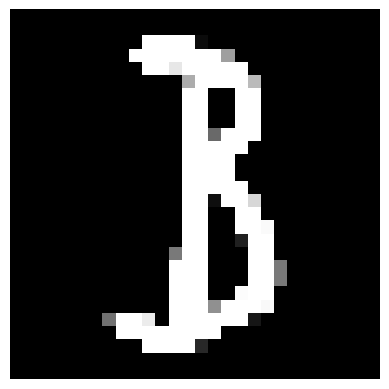

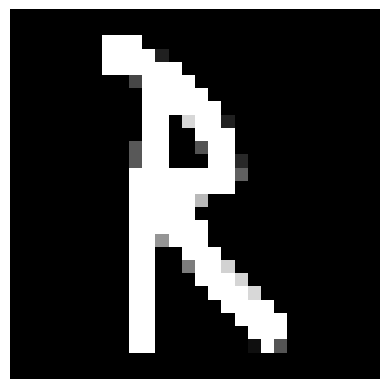

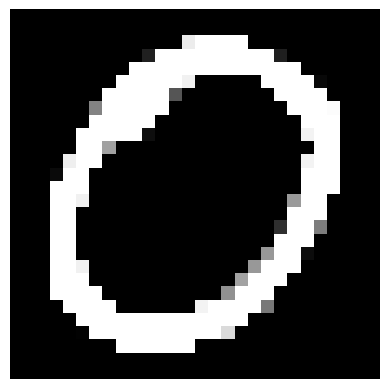

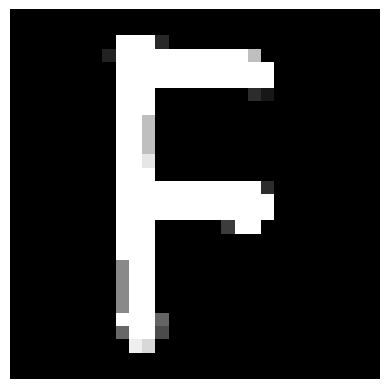

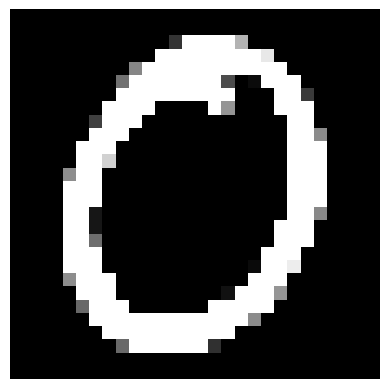

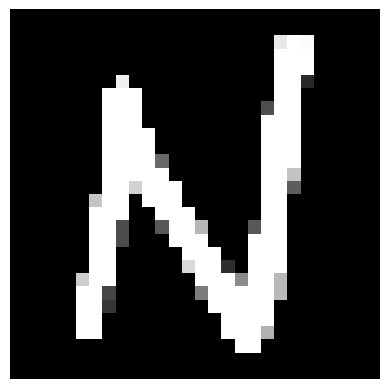

In [7]:
for _,subimg in segment_characters(binarize(images["pangram"])):
    plt.imshow(subimg,cmap="gray")
    plt.axis("off")
    plt.show()